In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("restaurant_deliveries.csv")
df

,Order Date,Customer Location Latitude,Customer Location Longitude
0,2024-10-30,-64.422765,-104.314848
1,2024-11-06,38.715505,-93.664296
2,2024-03-28,-82.208504,-13.563827
3,2024-11-24,88.750964,44.094277
4,2024-10-11,53.461366,-56.535313
...,...,...,...
49995,2024-07-31,16.003230,-110.385825
49996,2024-08-23,-51.499978,60.187253
49997,2024-02-14,-56.227167,137.400090
49998,2024-04-28,70.467715,-20.828838


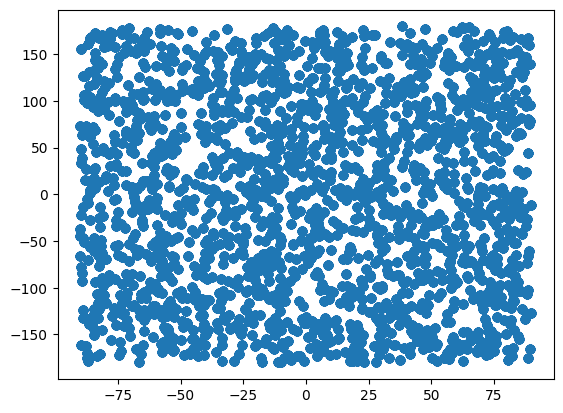

In [3]:
plt.scatter(x=df[["Customer Location Latitude"]],y=df[["Customer Location Longitude"]])
plt.show()

In [4]:
df = df[["Customer Location Latitude", "Customer Location Longitude"]]
df_numpy = df.to_numpy()
df_numpy

array([[ -64.42276475, -104.31484836],
       [  38.71550515,  -93.6642956 ],
       [ -82.20850419,  -13.56382651],
       ...,
       [ -56.22716659,  137.40009001],
       [  70.46771538,  -20.82883844],
       [ -53.70149882,  156.99580941]], shape=(50000, 2))

In [5]:
dbscan_demo = DBSCAN(
    eps=0.2,
    min_samples=15
)
dbscan_demo.fit(df_numpy)

DBSCAN(eps=0.2, min_samples=15)

In [6]:
df["Clusters"] = dbscan_demo.labels_
df

,Customer Location Latitude,Customer Location Longitude,Clusters
0,-64.422765,-104.314848,0
1,38.715505,-93.664296,1
2,-82.208504,-13.563827,2
3,88.750964,44.094277,3
4,53.461366,-56.535313,4
...,...,...,...
49995,16.003230,-110.385825,1550
49996,-51.499978,60.187253,1690
49997,-56.227167,137.400090,1728
49998,70.467715,-20.828838,1722


In [7]:
df["Clusters"].value_counts()

Clusters
-1       327
 178      50
 1021     42
 883      42
 579      41
        ... 
 637      15
 1830     15
 1802     15
 713      15
 31       15
Name: count, Length: 1974, dtype: int64

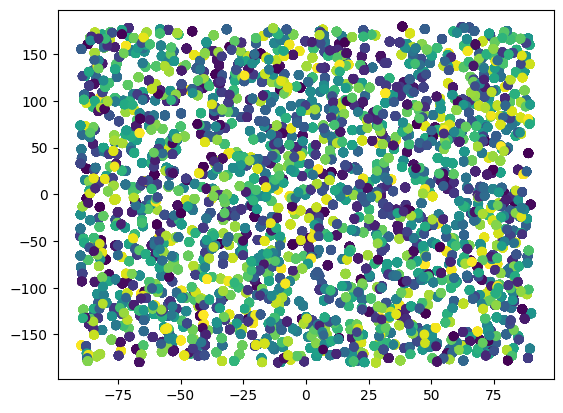

In [8]:
plt.scatter(
    x=df["Customer Location Latitude"],
    y=df["Customer Location Longitude"],
    c=df["Clusters"]
    )

In [9]:
silhouette_score(
    df[["Customer Location Latitude", "Customer Location Longitude"]],
    df["Clusters"]
)

np.float64(0.9870056794408575)

In [10]:
epsilons = np.linspace(
    0.01,
    1,
    num=30
)
min_samples = np.arange(
    2,
    100,
    step=2
)

In [13]:
combinations = list(itertools.product(epsilons,min_samples))

In [14]:
def get_scores_and_labels(combinations, X):
    scores = []
    all_labels_lists = []
    for i, (eps, num_samples) in enumerate(combinations):
        dbscan_multi = DBSCAN(eps=eps, min_samples=num_samples)
        dbscan_multi.fit(X)
        labels = dbscan_multi.labels_
        labels_set = set(labels)
        num_clusters = len(labels_set)
        if -1 in labels_set:
            num_clusters -= 1
        if (num_clusters < 2) or (num_clusters > 50):
            scores.append(-10)
            all_labels_lists.append("Bad")
            print(f"Combination {(eps, num_samples)} on iteration {i+1} of {len(combinations)} has {num_clusters} clusters. Moving on...")
            continue
        scores.append(silhouette_score(df_numpy, labels))
        all_labels_lists.append(labels)
        print(f"Index: {i}, Scores: {scores[-1]}, Labels: {all_labels_lists[-1]}, Number of Clusters: {num_clusters}")
    best_index = np.argmax(scores)
    best_parameters = combinations[best_index]
    best_labels = all_labels_lists[best_index]
    best_score = scores[best_index]
    return {
        "best_epsilon":best_parameters[0],
        "best_min_samples":best_parameters[1],
        "best_labels":best_labels,
        "best_score":best_score
    }

In [15]:
output_dict = get_scores_and_labels(combinations, df_numpy)

Combination (np.float64(0.01), np.int64(2)) on iteration 1 of 1470 has 2000 clusters. Moving on...
Combination (np.float64(0.01), np.int64(4)) on iteration 2 of 1470 has 2000 clusters. Moving on...
Combination (np.float64(0.01), np.int64(6)) on iteration 3 of 1470 has 2000 clusters. Moving on...
Combination (np.float64(0.01), np.int64(8)) on iteration 4 of 1470 has 2000 clusters. Moving on...
Combination (np.float64(0.01), np.int64(10)) on iteration 5 of 1470 has 2000 clusters. Moving on...
Combination (np.float64(0.01), np.int64(12)) on iteration 6 of 1470 has 1998 clusters. Moving on...
Combination (np.float64(0.01), np.int64(14)) on iteration 7 of 1470 has 1983 clusters. Moving on...
Combination (np.float64(0.01), np.int64(16)) on iteration 8 of 1470 has 1953 clusters. Moving on...
Combination (np.float64(0.01), np.int64(18)) on iteration 9 of 1470 has 1861 clusters. Moving on...
Combination (np.float64(0.01), np.int64(20)) on iteration 10 of 1470 has 1740 clusters. Moving on...
Com

KeyboardInterrupt: 